# Data Preprocessing and Feature Engineering in Machine Learning

## Assignment Objectives
This assignment demonstrates:

1. Data Exploration
2. Handling Missing Values
3. Feature Scaling
   - Standard Scaling
   - Min-Max Scaling
4. Encoding Techniques
   - One-Hot Encoding
   - Label Encoding
5. Feature Engineering
6. Feature Transformation
7. Comparison and Discussion

### Dataset
Adult Income Dataset

### Goal
Predict whether a person's income exceeds $50K per year based on census information.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

# Step 1: Load Dataset

The Adult dataset is loaded using Pandas and the first few records are displayed.

In [2]:
# Load datset

df = pd.read_csv("adult_with_headers (1).csv")

# Display first 5 rows
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Step 2: Basic Data Exploration

In this step we examine:

- Shape of dataset
- Data types
- Summary statistics
- Missing values

In [3]:
# Shape of dataset

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(32561, 15)


In [4]:
# Column names

print("Columns:")
print(df.columns.tolist())

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [5]:
# Data types

df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [6]:
# Summary statistics

df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
# Missing values

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

# Step 3: Handling Missing Values

The Adult dataset may contain missing values represented by '?'.

We replace '?' with NaN and then fill missing categorical values using the mode.

In [8]:
# Replace ? with NaN

df.replace(' ?', np.nan, inplace=True)

# check missing values

df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [9]:
# Fill missing categorical values using mode

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify missing values

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

# Step 4: Separate Numerical and Categorical Features

In [10]:
# Numerical columns

num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Categorical columns

cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical Features:")
print(num_cols)

print("\nCategorical Features:")
print(cat_cols)

Numerical Features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical Features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


# Step 5: Feature Scaling

Two scaling techniques are applied:

### Standard Scaling
Formula:

Z = (X - Mean) / Standard Deviation

Used when data follows normal distribution.

### Min-Max Scaling

Formula:

(X - Min)/(Max - Min)

Used when values need to be scaled between 0 and 1.

In [11]:
# Standard Scaling

standard_scaler = StandardScaler()

standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(df[num_cols]),
    columns=num_cols
)

standard_scaled.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


In [12]:
# Min-Max Scaling

minmax_scaler = MinMaxScaler()

minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(df[num_cols]),
    columns=num_cols
)

minmax_scaled.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


# Discussion: Standard Scaling vs Min-Max Scaling

### Standard Scaling

Advantages:
- Handles normally distributed data well.
- Useful for Logistic Regression and SVM.

Disadvantages:
- Does not bound values.

### Min-Max Scaling

Advantages:
- Scales data between 0 and 1.
- Useful for Neural Networks and KNN.

Disadvantages:
- Sensitive to outliers.

# Step 6: Encoding Techniques

Encoding converts categorical variables into numerical values.

### One-Hot Encoding
Used for columns having less than 5 unique categories.

### Label Encoding
Used for columns having more than 5 unique categories.

In [13]:
# Count unique values

for col in cat_cols:
    print(col, ":", df[col].nunique())

workclass : 8
education : 16
marital_status : 7
occupation : 14
relationship : 6
race : 5
sex : 2
native_country : 41
income : 2


In [14]:
# Columns having less than 5 unique categories

onehot_cols = [col for col in cat_cols if df[col].nunique() < 5]

print("One-Hot Columns:")
print(onehot_cols)

One-Hot Columns:
['sex', 'income']


In [15]:
# Apply One-Hot Encoding

onehot_df = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True
)

onehot_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,2174,0,40,United-States,True,False
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,13,United-States,True,False
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,40,United-States,True,False
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,40,United-States,True,False
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,40,Cuba,False,False


In [16]:
# Columns having more than 5 categories

label_cols = [col for col in cat_cols if df[col].nunique() >= 5]

print("Label Encoding Columns:")
print(label_cols)

Label Encoding Columns:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


In [17]:
# Apply Label Encoding

le = LabelEncoder()

label_encoded_df = df.copy()

for col in label_cols:
    label_encoded_df[col] = le.fit_transform(label_encoded_df[col])

label_encoded_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,6,77516,9,13,4,0,1,4,Male,2174,0,40,38,<=50K
1,50,5,83311,9,13,2,3,0,4,Male,0,0,13,38,<=50K
2,38,3,215646,11,9,0,5,1,4,Male,0,0,40,38,<=50K
3,53,3,234721,1,7,2,5,0,2,Male,0,0,40,38,<=50K
4,28,3,338409,9,13,2,9,5,2,Female,0,0,40,4,<=50K


# Discussion: One-Hot Encoding vs Label Encoding

## One-Hot Encoding

Advantages:
- No ordinal relationship introduced.
- Suitable for nominal data.

Disadvantages:
- Creates many new columns.

## Label Encoding

Advantages:
- Simple and memory efficient.

Disadvantages:
- May introduce false ordering.

# Step 7: Feature Engineering

Two new features are created:

1. Net_Capital
   - Capital Gain - Capital Loss

2. Age_Hours_Product
   - Age × Hours Worked Per Week

These may provide additional information to the machine learning model.

In [18]:
# STEP 7: FEATURE ENGINEERING 

# 1. Net Capital calculated properly (Gain - Loss)
df['Net_Capital'] = df['capital_gain'] - df['capital_loss']

# 2. Lifetime Labor Intensity Interaction Feature
df['Age_Hours_Product'] = df['age'] * df['hours_per_week']

# 3. Log Transformation for highly skewed 'capital_gain' feature
df['capital_gain_log'] = np.log1p(df['capital_gain'])

# ---- VERIFICATION ----
print(" added new features!")
print("Dataset Columns:", df.columns.tolist())

df[['Net_Capital', 'Age_Hours_Product', 'capital_gain_log']].head()

 added new features!
Dataset Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income', 'Net_Capital', 'Age_Hours_Product', 'capital_gain_log']


,Net_Capital,Age_Hours_Product,capital_gain_log
0,2174,1560,7.684784
1,0,650,0.000000
2,0,1520,0.000000
3,0,2120,0.000000
4,0,1120,0.000000


# Feature Engineering Rationale

### Total_Capital
Combines gain and loss information into a single financial indicator.

### Age_Hours_Product
Represents combined effect of age and working hours which may influence income level.

# Step 8: Identify Skewed Numerical Features

A skewed feature is transformed using Log Transformation.

In [19]:
# Calculate skewness

skewness = df[num_cols].skew()

print(skewness.sort_values(ascending=False))

capital_gain      11.953848
capital_loss       4.594629
fnlwgt             1.446980
age                0.558743
hours_per_week     0.227643
education_num     -0.311676
dtype: float64


In [20]:
# Log Transformation on Capital Gain

df['capital_gain_log'] = np.log1p(df['capital_gain'])

df[['capital_gain','capital_gain_log']].head()

,capital_gain,capital_gain_log
0,2174,7.684784
1,0,0.000000
2,0,0.000000
3,0,0.000000
4,0,0.000000


# Isolation Forest for Outlier Detection

Isolation Forest is an unsupervised machine learning algorithm used to detect anomalies (outliers) in the dataset. It helps identify unusual observations that may negatively affect model performance.

In [21]:
from sklearn.ensemble import IsolationForest

# Numerical columns only
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Isolation Forest Model
iso = IsolationForest(contamination=0.05, random_state=42)

# Detect Outliers
outliers = iso.fit_predict(num_cols)

# Count Outliers
print("Number of Outliers:", (outliers == -1).sum())

Number of Outliers: 1628


# PPS (Predictive Power Score) Analysis

PPS measures the predictive strength between features and the target variable. Unlike correlation, PPS can detect both linear and non-linear relationships.

In [22]:
!pip install ppscore

In [23]:
import ppscore as pps

pps_df = pps.matrix(df)

pps_df[['x', 'y', 'ppscore']].sort_values(
    by='ppscore',
    ascending=False
).head(10)

,x,y,ppscore
0,age,age,1.0
152,race,race,1.0
57,education,education,1.0
58,education,education_num,1.0
75,education_num,education,1.0
76,education_num,education_num,1.0
95,marital_status,marital_status,1.0
114,occupation,occupation,1.0
133,relationship,relationship,1.0
171,sex,sex,1.0


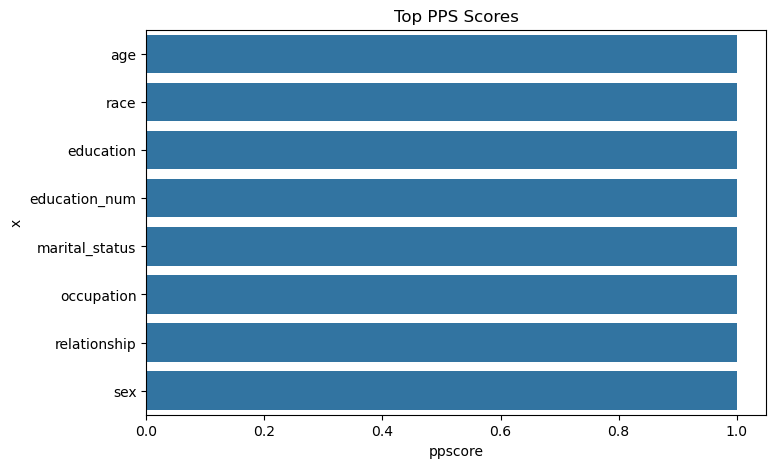

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

top_pps = pps_df.sort_values(
    by='ppscore',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    data=top_pps,
    x='ppscore',
    y='x'
)

plt.title("Top PPS Scores")
plt.show()

## Interpretation

- Isolation Forest detected anomalous observations in the dataset.
- PPS analysis identified the most predictive features for income classification.
- Features with higher PPS scores have stronger predictive power and may be useful for model building.

# Why Log Transformation?

Capital Gain is highly right-skewed.

Log transformation:

- Reduces skewness
- Improves distribution
- Helps machine learning algorithms learn patterns effectively

In [25]:
# Final dataset

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,Net_Capital,Age_Hours_Product,capital_gain_log
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,2174,1560,7.684784
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0,650,0.000000
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0,1520,0.000000
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0,2120,0.000000
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0,1120,0.000000


# Conclusion

The following preprocessing and feature engineering techniques were successfully applied:

1. Missing Value Handling
2. Standard Scaling
3. Min-Max Scaling
4. One-Hot Encoding
5. Label Encoding
6. Feature Engineering
7. Log Transformation

These steps improve data quality and help machine learning models achieve better performance.